# Part A: Data preprocessing 

0. Imports and configs 


In [1]:
import os
import random
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter
import tensorflow as tf

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

IMAGES_DIR = Path("data/images/Images")
ANNOTATIONS_DIR = Path("data/annotations/Annotation")

I0000 00:00:1777307801.960361 3483159 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777307802.030155 3483159 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777307804.203333 3483159 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1. Functions 

In [2]:
def load_and_preprocess(image_path, label):
    """Load image, decodes the jpeg, resize, normalize, and return as tensor"""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label


def build_dataset(paths, labels, shuffle=False):
    """Takes in the image paths, labels, and returns a tf.data.Dataset 
    where the first column is the imagepath  and the second column is the label"""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)) #creates a dataset from the input tensors
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE) #applies the load_and_preprocess function to each element of the dataset
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) #batches the dataset and prefetches the next batch
    return ds


def plot_breed_distribution(y_train, y_val, y_test, label_to_breed, num_classes):
    """Grouped horizontal bar chart of samples per breed across splits."""
    breed_names = [label_to_breed[i] for i in range(num_classes)]
    train_counts = [np.sum(y_train == i) for i in range(num_classes)]
    val_counts   = [np.sum(y_val == i)   for i in range(num_classes)]
    test_counts  = [np.sum(y_test == i)  for i in range(num_classes)]

    y_pos = np.arange(num_classes)
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.barh(y_pos - bar_h, train_counts, bar_h, label=f"Train ({len(y_train)})", color="#4c72b0")
    ax.barh(y_pos,         val_counts,   bar_h, label=f"Val ({len(y_val)})",     color="#55a868")
    ax.barh(y_pos + bar_h, test_counts,  bar_h, label=f"Test ({len(y_test)})",   color="#c44e52")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(breed_names, fontsize=9)
    ax.set_xlabel("Number of Images")
    ax.set_title("Samples per Breed by Split")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


2. Downlaoding the data, donwloads only once

#set up kaggle credential for download


In [3]:


DATA_DIR = Path("data")

if not DATA_DIR.exists():
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "jessicali9530/stanford-dogs-dataset", "--unzip", "-p", "./data"],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print("Dataset downloaded and extracted to ./data")
    else:
        stderr = (result.stderr or "").strip()
        missing_auth = (
            "KeyError: 'username'" in stderr
            or "Could not find kaggle.json" in stderr
            or "credentials" in stderr.lower()
        )

        if missing_auth:
            print("Kaggle credentials were not found on this machine.")
            print("Each user should configure their own Kaggle account locally:")
            print("  1) Create ~/.kaggle/kaggle.json with your own username and API key")
            print("  2) Run: chmod 600 ~/.kaggle/kaggle.json")
            print("  3) Re-run this cell")
        else:
            print(f"Download failed:\n{stderr}")
else:
    print("Dataset already exists at ./data")

Dataset already exists at ./data


2. Breed selection and label mapping

In [4]:
SELECTED_BREEDS = [
    "n02085620-Chihuahua",
    "n02086240-Shih-Tzu",
    "n02087394-Rhodesian_ridgeback",
    "n02088364-beagle",
    "n02089973-English_foxhound",
    "n02091032-Italian_greyhound",
    "n02092339-Weimaraner",
    "n02093256-Staffordshire_bullterrier",
    "n02094433-Yorkshire_terrier",
    "n02096585-Boston_bull",
    "n02097047-miniature_schnauzer",
    "n02099601-golden_retriever",
    "n02099712-Labrador_retriever",
    "n02100877-Irish_setter",
    "n02102318-cocker_spaniel",
    "n02105855-Shetland_sheepdog",
    "n02106166-Border_collie",
    "n02106382-Bouvier_des_Flandres",
    "n02106550-Rottweiler",
    "n02106662-German_shepherd",
    "n02107142-Doberman",
    "n02107683-Bernese_mountain_dog",
    "n02108089-boxer",
    "n02108915-French_bulldog",
    "n02109047-Great_Dane",
    "n02109525-Saint_Bernard",
    "n02110185-Siberian_husky",
    "n02110958-pug",
    "n02111889-Samoyed",
    "n02112018-Pomeranian",
]

breed_to_label = {breed: i for i, breed in enumerate(SELECTED_BREEDS)} #labels are numerical class
label_to_breed = {i: breed.split("-", 1)[1] for i, breed in enumerate(SELECTED_BREEDS)}
NUM_CLASSES = len(SELECTED_BREEDS)

print(f"Selected {NUM_CLASSES} breeds:")
for i, breed in label_to_breed.items():
    print(f"  {i:2d}: {breed}")

Selected 30 breeds:
   0: Chihuahua
   1: Shih-Tzu
   2: Rhodesian_ridgeback
   3: beagle
   4: English_foxhound
   5: Italian_greyhound
   6: Weimaraner
   7: Staffordshire_bullterrier
   8: Yorkshire_terrier
   9: Boston_bull
  10: miniature_schnauzer
  11: golden_retriever
  12: Labrador_retriever
  13: Irish_setter
  14: cocker_spaniel
  15: Shetland_sheepdog
  16: Border_collie
  17: Bouvier_des_Flandres
  18: Rottweiler
  19: German_shepherd
  20: Doberman
  21: Bernese_mountain_dog
  22: boxer
  23: French_bulldog
  24: Great_Dane
  25: Saint_Bernard
  26: Siberian_husky
  27: pug
  28: Samoyed
  29: Pomeranian


3. Goes through each image, the image is added to img_paths list, the bounding boxes are ignored, and the label(which is the dog bread) is added to the labels list. 

In [5]:
image_paths = []  #array of image paths
labels = [] #array of labels which is the dog bread
skipped = 0 #number of images skipped



for breed_folder in SELECTED_BREEDS:
    label = breed_to_label[breed_folder]
    img_dir = IMAGES_DIR / breed_folder
    ann_dir = ANNOTATIONS_DIR / breed_folder

    for img_file in sorted(img_dir.glob("*.jpg")):
        ann_file = ann_dir / img_file.stem
        if not ann_file.exists():
            skipped += 1
            continue
        try:
            image_paths.append(str(img_file))
            labels.append(label)
        except Exception:
            skipped += 1

image_paths = np.array(image_paths)
labels = np.array(labels)

print(f"Total samples: {len(image_paths)} (skipped {skipped})")
print(f"Labels shape: {labels.shape}")
print(f"\nSamples per breed:")
counts = Counter(labels)
for lbl in sorted(counts):
    print(f"  {label_to_breed[lbl]:30s}: {counts[lbl]}")

Total samples: 5116 (skipped 0)
Labels shape: (5116,)

Samples per breed:
  Chihuahua                     : 152
  Shih-Tzu                      : 214
  Rhodesian_ridgeback           : 172
  beagle                        : 195
  English_foxhound              : 157
  Italian_greyhound             : 182
  Weimaraner                    : 160
  Staffordshire_bullterrier     : 155
  Yorkshire_terrier             : 164
  Boston_bull                   : 182
  miniature_schnauzer           : 154
  golden_retriever              : 150
  Labrador_retriever            : 171
  Irish_setter                  : 155
  cocker_spaniel                : 159
  Shetland_sheepdog             : 157
  Border_collie                 : 150
  Bouvier_des_Flandres          : 150
  Rottweiler                    : 152
  German_shepherd               : 152
  Doberman                      : 150
  Bernese_mountain_dog          : 218
  boxer                         : 151
  French_bulldog                : 159
  Great_Dane  

4. Stratified split: 70% train, 15% validation, 15% test
stratify=labels ensures each breed has the same proportion in every split

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split( #splits into 70% train, and 30% temp
    image_paths, labels,
    test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split( #the 30 temp is split into 15% val and 15% test
    X_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

print(f"\nBreed distribution check (first 5 breeds):")
for lbl in range(5):
    name = label_to_breed[lbl]
    tr = np.sum(y_train == lbl)
    va = np.sum(y_val == lbl)
    te = np.sum(y_test == lbl)
    print(f"  {name:25s} -> train={tr}, val={va}, test={te}")

Train:      3581 samples
Validation: 767 samples
Test:       768 samples

Breed distribution check (first 5 breeds):
  Chihuahua                 -> train=106, val=23, test=23
  Shih-Tzu                  -> train=150, val=32, test=32
  Rhodesian_ridgeback       -> train=120, val=26, test=26
  beagle                    -> train=137, val=29, test=29
  English_foxhound          -> train=110, val=24, test=23


5. Breed distribution across each split

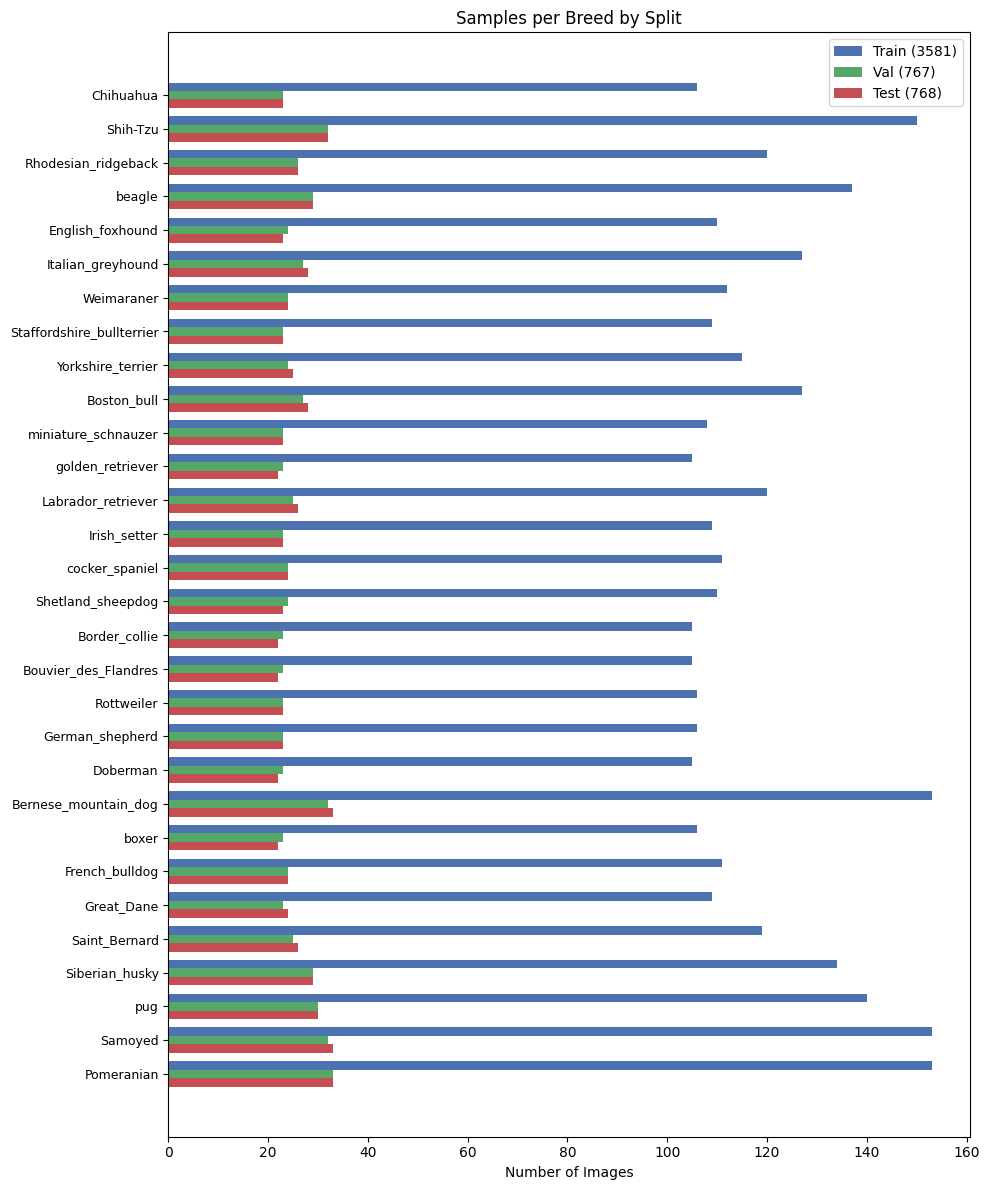

In [7]:
plot_breed_distribution(y_train, y_val, y_test, label_to_breed, NUM_CLASSES)

6. Sanity Check: checking one batch of the trainig to make sure everything is build correctly. 

In [8]:
cls_train_ds = build_dataset(X_train, y_train, shuffle=True) #loads the data into a dataset for training
cls_val_ds = build_dataset(X_val, y_val) #loads the data into a dataset for validation
cls_test_ds = build_dataset(X_test, y_test) #loads the data into a dataset for testing

for images, targets in cls_train_ds.take(1):
    print(f"Image batch shape:  {images.shape}")
    print(f"Labels batch shape: {targets.shape}")
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Image batch shape:  (32, 224, 224, 3)
Labels batch shape: (32,)
Pixel range: [0.00, 1.00]


W0000 00:00:1777307810.015193 3483252 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777307810.116591 3483159 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


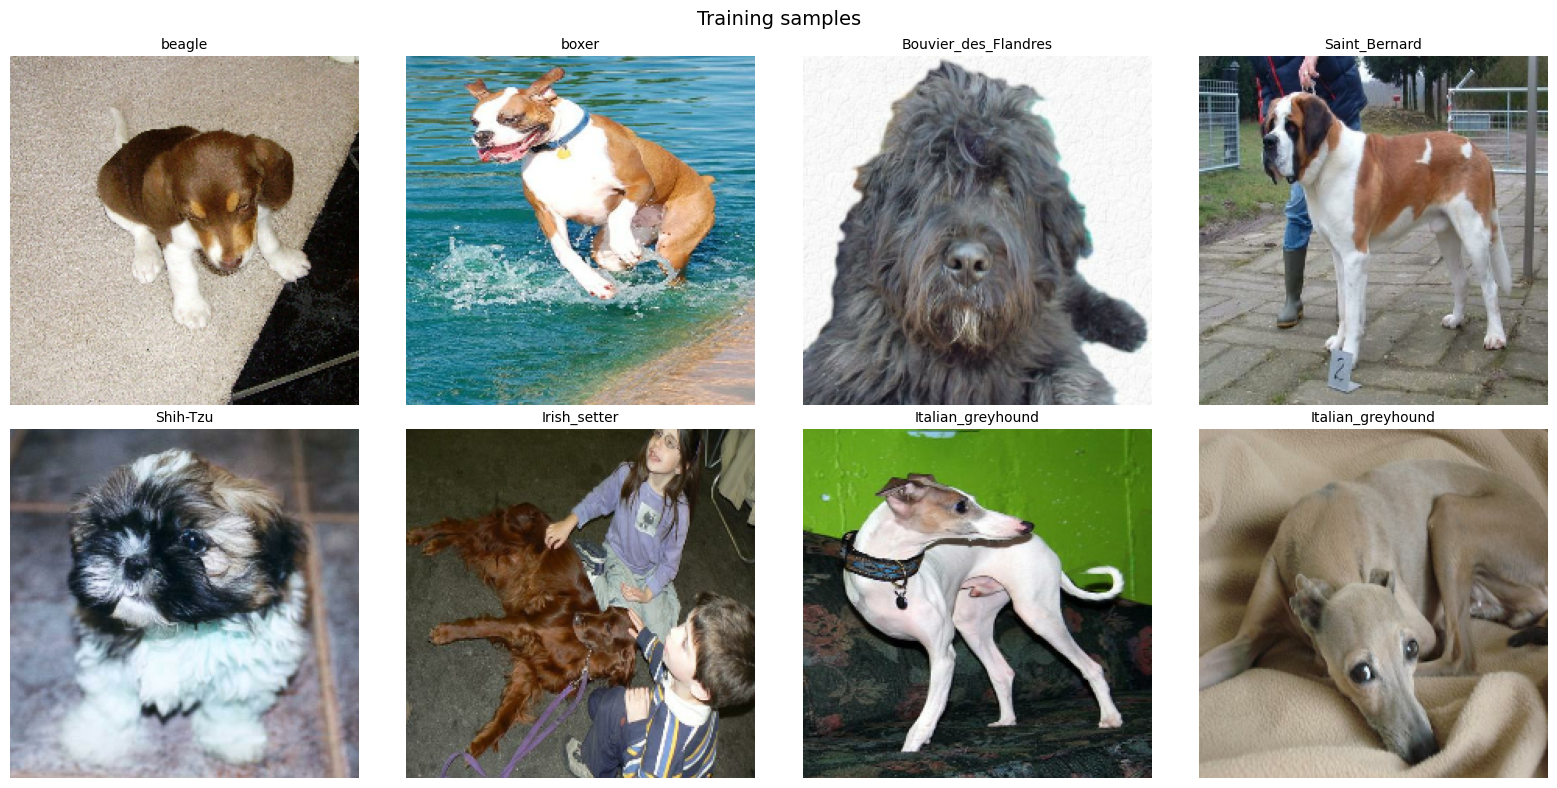

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for images, targets in cls_train_ds.take(1):
    for i in range(8):
        img = images[i].numpy()
        label = targets[i].numpy()

        h, w = IMG_SIZE, IMG_SIZE

        axes[i].imshow(img)
        axes[i].set_title(label_to_breed[label], fontsize=10)
        axes[i].axis("off")

plt.suptitle("Training samples", fontsize=14)
plt.tight_layout()
plt.show()

# Part B: Model Develpment

# Baseline CNN

In [10]:
simple_model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

simple_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

simple_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

simple_history = simple_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=20,
    callbacks=simple_callbacks,
    verbose=1
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0380 - loss: 3.3996 - val_accuracy: 0.0430 - val_loss: 3.3857 - learning_rate: 1.0000e-04
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.0832 - loss: 3.3286 - val_accuracy: 0.0756 - val_loss: 3.2705 - learning_rate: 1.0000e-04
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.1148 - loss: 3.1910 - val_accuracy: 0.1213 - val_loss: 3.1526 - learning_rate: 1.0000e-04
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.1427 - loss: 3.0709 - val_accuracy: 0.1082 - val_loss: 3.0643 - learning_rate: 1.0000e-04
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.1737 - loss: 2.9661 - val_accuracy: 0.1304 - val_loss: 3.0394 - learning_rate: 1.0000e-04
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.2011 - loss: 2.8475 - val_accuracy: 0.1525 - val_loss: 2.9887 - learning_rate: 1.0000e-04
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - ac

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1849 - loss: 2.9712


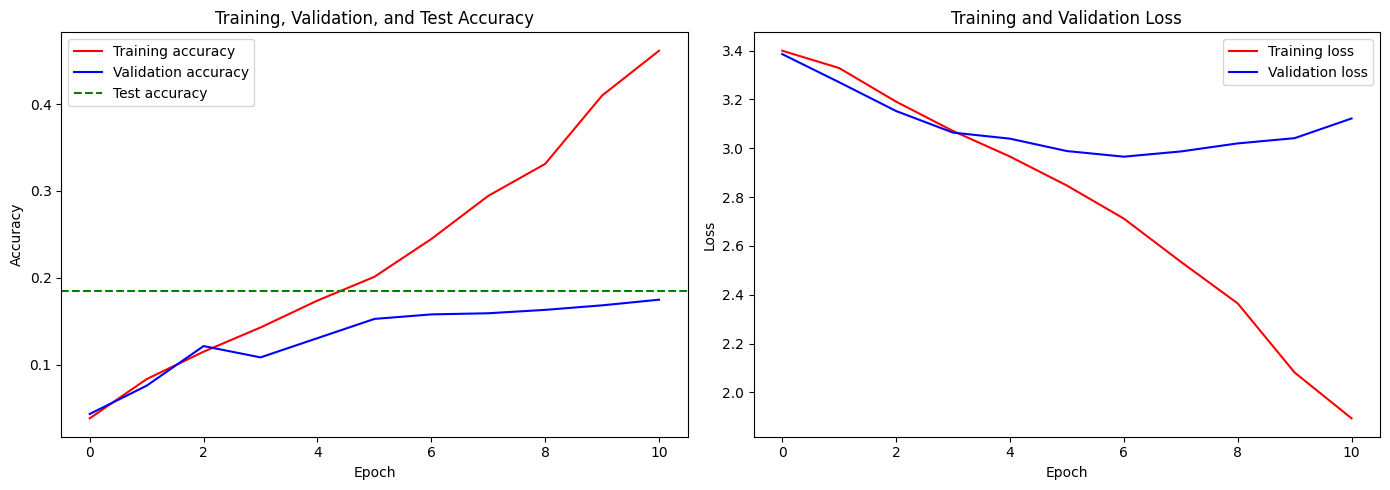

In [11]:
test_loss, test_acc = simple_model.evaluate(cls_test_ds)

train_acc = simple_history.history['accuracy']
val_acc   = simple_history.history['val_accuracy']
train_loss = simple_history.history['loss']
val_loss   = simple_history.history['val_loss']

epochs = range(len(train_acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, 'r', label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', label='Validation accuracy')
ax1.axhline(y=test_acc, color='g', linestyle='--', label='Test accuracy')
ax1.set_title('Training, Validation, and Test Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs, train_loss, 'r', label='Training loss')
ax2.plot(epochs, val_loss, 'b', label='Validation loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
test_loss, test_acc = simple_model.evaluate(cls_test_ds)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1849 - loss: 2.9712
Test accuracy: 0.1849
Test loss: 2.9712


# Custom CNN

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.05),
], name="cnn_data_augmentation")

def build_best_cnn(img_size, num_classes):
    return tf.keras.models.Sequential([
        tf.keras.Input(shape=(img_size, img_size, 3)),
        data_augmentation,

        # Block 1
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.10),

        # Block 2
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.15),

        # Block 3
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.20),

        # Block 4
        tf.keras.layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.25),

        # Block 5
        tf.keras.layers.Conv2D(384, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(384, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.30),

        # Head
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4)
        ),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ], name="best_breed_cnn")

In [14]:
best_cnn = build_best_cnn(IMG_SIZE, NUM_CLASSES)

best_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

best_cnn_history = best_cnn.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=60,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 116s 977ms/step - accuracy: 0.0514 - loss: 3.5097 - val_accuracy: 0.0430 - val_loss: 3.5588 - learning_rate: 3.0000e-04
Epoch 2/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 108s 965ms/step - accuracy: 0.0776 - loss: 3.3592 - val_accuracy: 0.0456 - val_loss: 3.5122 - learning_rate: 3.0000e-04
Epoch 3/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 108s 961ms/step - accuracy: 0.0846 - loss: 3.3103 - val_accuracy: 0.0535 - val_loss: 3.7676 - learning_rate: 3.0000e-04
Epoch 4/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 108s 963ms/step - accuracy: 0.0969 - loss: 3.2438 - val_accuracy: 0.0626 - val_loss: 3.6379 - learning_rate: 3.0000e-04
Epoch 5/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 108s 963ms/step - accuracy: 0.1159 - loss: 3.1789 - val_accuracy: 0.0874 - val_loss: 4.4153 - learning_rate: 3.0000e-04
Epoch 6/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 109s 969ms/step - accuracy: 0.1377 - loss: 3.0797 - val_accuracy: 0.1239 - val_loss: 3.2325 - learning_rate: 1.5000e-04
Epoch 7/60
112/112 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
test_loss, test_acc = best_cnn.evaluate(cls_test_ds, verbose=1)
print(f"Best CNN test accuracy: {test_acc:.4f}")
print(f"Best CNN test loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.3255 - loss: 2.3715
Best CNN test accuracy: 0.3255
Best CNN test loss: 2.3715


# ResNet Model

In [16]:
layers = tf.keras.layers
models = tf.keras.models
ResNet50 = tf.keras.applications.ResNet50
preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [18]:
def build_resnet_model():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    x = tf.keras.layers.Rescaling(255.0)(x)
    x = tf.keras.applications.resnet50.preprocess_input(x)

    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

In [19]:
resnet_model, resnet_base = build_resnet_model()

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

In [20]:
resnet_history_frozen = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=10,
    callbacks=resnet_callbacks
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 54s 414ms/step - accuracy: 0.5387 - loss: 1.6868 - val_accuracy: 0.8840 - val_loss: 0.3945 - learning_rate: 0.0010
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 391ms/step - accuracy: 0.7894 - loss: 0.7107 - val_accuracy: 0.8814 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 45s 404ms/step - accuracy: 0.8176 - loss: 0.5910 - val_accuracy: 0.9126 - val_loss: 0.2920 - learning_rate: 0.0010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 392ms/step - accuracy: 0.8383 - loss: 0.5165 - val_accuracy: 0.9087 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 393ms/step - accuracy: 0.8604 - loss: 0.4230 - val_accuracy: 0.9113 - val_loss: 0.3062 - learning_rate: 0.0010
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 392ms/step - accuracy: 0.8752 - loss: 0.3866 - val_accuracy: 0.8983 - val_loss: 0.3291 - learning_rate: 0.0010
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 44s 394ms/step - accuracy: 0.8

In [21]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-50]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_history_finetune = resnet_model.fit(
    cls_train_ds,
    validation_data=cls_val_ds,
    epochs=15,
    callbacks=resnet_callbacks
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 84s 607ms/step - accuracy: 0.8679 - loss: 0.4238 - val_accuracy: 0.9153 - val_loss: 0.2834 - learning_rate: 1.0000e-05
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 69s 615ms/step - accuracy: 0.9020 - loss: 0.3272 - val_accuracy: 0.9166 - val_loss: 0.2811 - learning_rate: 1.0000e-05
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 79s 592ms/step - accuracy: 0.9025 - loss: 0.3059 - val_accuracy: 0.9205 - val_loss: 0.2896 - learning_rate: 2.0000e-06
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 66s 593ms/step - accuracy: 0.9132 - loss: 0.2710 - val_accuracy: 0.9166 - val_loss: 0.2904 - learning_rate: 2.0000e-06


In [22]:
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(cls_test_ds)

print(f"ResNet Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet Test Accuracy: {resnet_test_acc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.8997 - loss: 0.3005
ResNet Test Loss: 0.3005
ResNet Test Accuracy: 0.8997


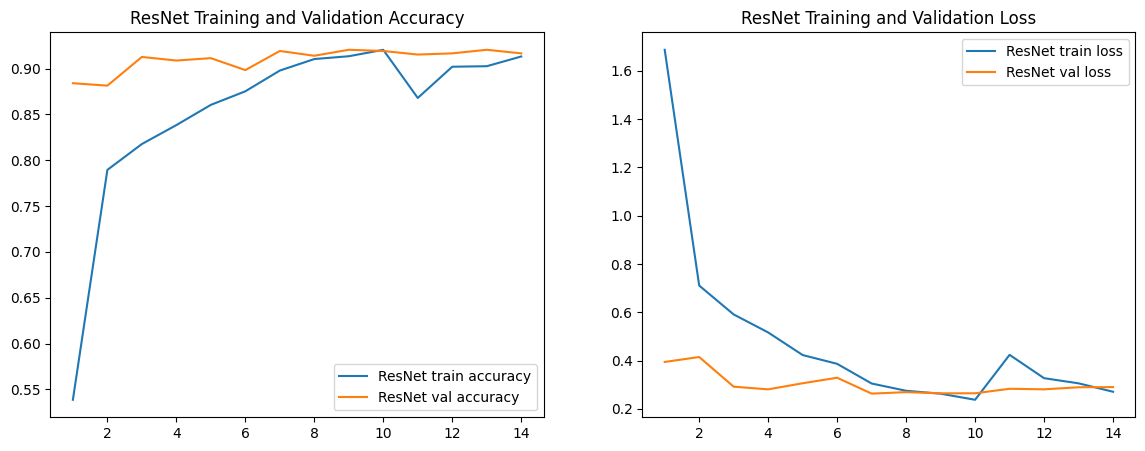

In [23]:
resnet_acc = (
    resnet_history_frozen.history['accuracy']
    + resnet_history_finetune.history['accuracy']
)
resnet_val_acc = (
    resnet_history_frozen.history['val_accuracy']
    + resnet_history_finetune.history['val_accuracy']
)
resnet_loss = (
    resnet_history_frozen.history['loss']
    + resnet_history_finetune.history['loss']
)
resnet_val_loss = (
    resnet_history_frozen.history['val_loss']
    + resnet_history_finetune.history['val_loss']
)

resnet_epochs = range(1, len(resnet_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(resnet_epochs, resnet_acc, label='ResNet train accuracy')
ax1.plot(resnet_epochs, resnet_val_acc, label='ResNet val accuracy')
ax1.set_title('ResNet Training and Validation Accuracy')
ax1.legend()

ax2.plot(resnet_epochs, resnet_loss, label='ResNet train loss')
ax2.plot(resnet_epochs, resnet_val_loss, label='ResNet val loss')
ax2.set_title('ResNet Training and Validation Loss')
ax2.legend()

plt.show()